# Boosted Decision Tree Skeleton


In this cell, split the dataset into _train_ and _test_ samples, using sci-kit learn `train_test_split()`.


In [137]:
import sys
sys.path.append("/users/xn22103/atmospherics-tools/fast-osc-feedback/")

import polars as pl
import uproot
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt

#data loading and preprocessing

caf_tree = uproot.open("/storage/1/st15719/caf_new_sum.2.6M_weighted.root")["cafTree"]

#reco variables
# Enu_e_had= "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.e_had"
# Enu_e_calo = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.e_calo"
# Enu_mu_had= "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.mu_had"
# Enu_mu_range= "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.mu_range"

#true variables
ineasticity = "rec/mc/mc.nu/mc.nu.inelasticity"
PDG = "rec/mc/mc.nu/mc.nu.pdg"

# caf_data = caf_tree.arrays([Enu_e_had, Enu_e_calo, Enu_mu_had, Enu_mu_range, PDG])
caf_data = caf_tree.arrays([ineasticity, PDG])

caf_df = pl.from_pandas(ak.to_dataframe(caf_data, how = "outer"))
# caf_df.columns = ["Enu_e_had","Enu_e_calo","Enu_mu_had","Enu_mu_range","PDG"]
caf_df.columns = ["inelasticity","PDG"]

print(len(caf_df))

event_daughters = uproot.open("event_daughters_info.root")["event_daughters_tree"]
event_daughters_df = pl.from_pandas(event_daughters.arrays(library="pd"))

print(len(event_daughters_df))

data = pl.concat([caf_df, event_daughters_df], how="horizontal")

print(len(data))

data = data.with_row_index("event_index")

#dont need reco check for truth info for truth test of bdt
# data = data.filter(pl.col("reco_ok") == True)

print(len(data))


data = data.with_columns(
# 	(1 - (pl.col("Enu_e_had") / pl.col("Enu_e_calo"))).alias("inelasticity_e"),
# 	(1 - (pl.col("Enu_mu_had") / pl.col("Enu_mu_range"))).alias("inelasticity_mu"),
	(pl.col("PDG") < 0).cast(pl.Int64).alias("label"))



data = data.to_pandas()
data = data.dropna()


2884703
2884703
2884703
2884703


In [138]:
data.columns

Index(['event_index', 'inelasticity', 'PDG', 'reco_ok', 'n_reco_pfps',
       'n_reco_tracks', 'n_reco_showers', 'single_hits_energy',
       'n_reco_muons_pions', 'n_reco_protons', 'n_true_nu',
       'n_primary_daughters', 'n_primary_electrons', 'n_primary_muons',
       'n_primary_protons', 'n_primary_pions', 'n_primary_photons',
       'n_primary_pi0s', 'n_primary_tracks', 'n_primary_showers', 'label'],
      dtype='object')

In [139]:
data

,event_index,inelasticity,PDG,reco_ok,n_reco_pfps,n_reco_tracks,n_reco_showers,single_hits_energy,n_reco_muons_pions,n_reco_protons,...,n_primary_daughters,n_primary_electrons,n_primary_muons,n_primary_protons,n_primary_pions,n_primary_photons,n_primary_pi0s,n_primary_tracks,n_primary_showers,label
0,0,0.097032,-12,True,10,5,4,11.487990,4,1,...,5,1,0,0,1,0,1,1,3,1
1,1,0.543771,-12,True,2,1,0,0.110940,1,0,...,4,1,0,1,0,1,0,1,1,1
2,2,0.464560,-14,True,4,3,0,0.064570,2,1,...,6,0,1,0,2,0,0,3,0,1
3,3,0.140807,16,False,-1,-1,-1,-1.000000,-1,-1,...,8,0,0,1,0,0,0,1,0,0
4,4,0.208293,14,True,3,2,0,0.002420,1,1,...,3,0,1,1,0,1,0,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2884698,2884698,0.597658,14,True,2,1,0,0.000000,1,0,...,3,0,0,1,0,1,0,1,0,0
2884699,2884699,0.171440,14,True,2,1,0,0.005397,1,0,...,3,0,1,1,0,0,0,2,0,0
2884700,2884700,0.307673,14,True,3,1,1,0.012165,1,0,...,6,0,1,2,0,1,0,3,0,0
2884701,2884701,0.220781,12,True,3,1,1,0.102556,0,1,...,4,0,0,1,0,0,1,1,2,0


In [140]:
import pandas as pd

consistency = pd.crosstab(data['PDG'] < 0, data['label'])
consistency.index = ['PDG > 0 (Nu)', 'PDG < 0 (Anti-Nu)']
consistency.columns = ['Label 0', 'Label 1']
print(consistency)

                   Label 0  Label 1
PDG > 0 (Nu)       2139536        0
PDG < 0 (Anti-Nu)        0   745167


In [141]:
electron_mask = data['PDG'].abs() == 12
muon_mask = data['PDG'].abs() == 14
tau_mask = data['PDG'].abs() == 16


electron_data = data[electron_mask]
muon_data = data[muon_mask] 
tau_data = data[tau_mask]
data_pfp_1 = data[data["n_reco_pfps"] > 1]
# data_E_10gev = data_pfp_1[data_pfp_1["E"] > 10]

In [142]:
data_type = data_pfp_1


# feature_columns = ['inelasticity', 'single_hits_energy',
#        'n_reco_muons_pions', 'n_reco_protons', 'n_true_nu',
#        'n_primary_daughters', 'n_primary_electrons', 'n_primary_muons',
#        'n_primary_protons', 'n_primary_pions', 'n_primary_photons',
#        'n_primary_pi0s', 'n_primary_tracks', 'n_primary_showers']
# data = data_type.dropna()

feature_columns = ['inelasticity',
       'n_primary_daughters', 'n_primary_electrons', 'n_primary_muons',
       'n_primary_protons', 'n_primary_pions', 'n_primary_photons',
        'n_primary_tracks']
data = data_type.dropna()

# for col in [
# 	"single_hits_energy",
# 	"n_reco_pfps",
# 	"n_reco_tracks",
# 	"n_reco_showers",
# 	"n_reco_protons",
# ]:
# 	data[col] = np.log1p(data[col])


X_data = data_type[feature_columns].values


y_data = data_type['label'].values

data_type[feature_columns]

,inelasticity,n_primary_daughters,n_primary_electrons,n_primary_muons,n_primary_protons,n_primary_pions,n_primary_photons,n_primary_tracks
0,0.097032,5,1,0,0,1,0,1
1,0.543771,4,1,0,1,0,1,1
2,0.464560,6,0,1,0,2,0,3
4,0.208293,3,0,1,1,0,1,2
5,0.357354,3,0,0,1,0,1,1
...,...,...,...,...,...,...,...,...
2884698,0.597658,3,0,0,1,0,1,1
2884699,0.171440,3,0,1,1,0,0,2
2884700,0.307673,6,0,1,2,0,1,3
2884701,0.220781,4,0,0,1,0,0,1


In [143]:
print(np.unique(y_data, return_counts=True))


(array([0, 1]), array([1981454,  669573]))


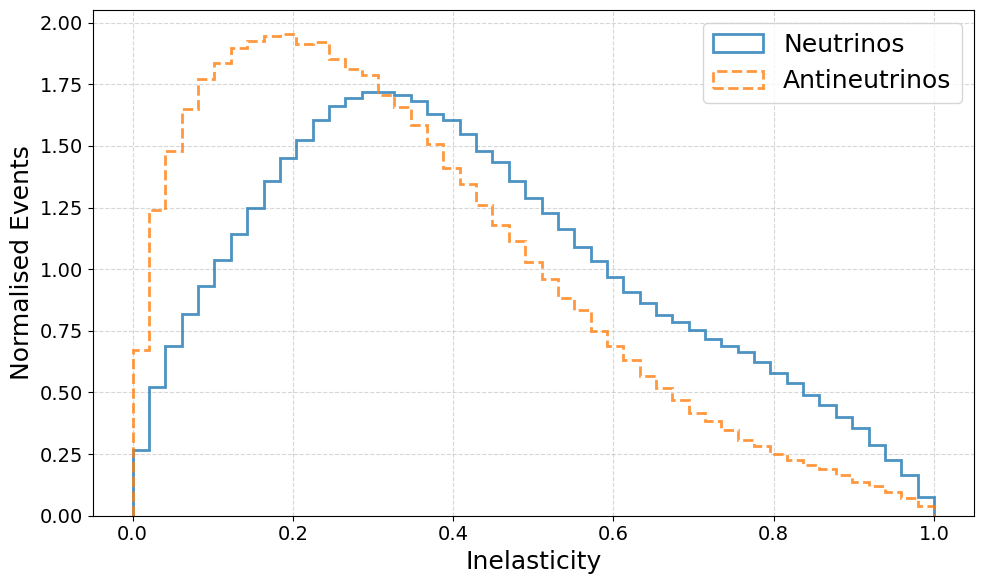

In [144]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

neutrinos = data[data['label'] == 0]
antineutrinos = data[data['label'] == 1]

def set_plot_style():
	plt.rcParams.update({
		"font.size": 12,
		"axes.labelsize": 18,
		"xtick.labelsize": 14,
		"ytick.labelsize": 14,
		"legend.fontsize": 18,
		"lines.linewidth": 1.5
	})
	
set_plot_style()

all_neutrinos = pd.concat([neutrinos['inelasticity']])
all_antineutrinos = pd.concat([antineutrinos['inelasticity']])

fig, ax = plt.subplots(figsize=(10, 6))

bins = np.linspace(0, 1, 50)

ax.hist(all_neutrinos, bins=bins, alpha=0.8, density=True, histtype='step', linewidth=2, label='Neutrinos')
ax.hist(all_antineutrinos, bins=bins, alpha=0.8, density=True, histtype='step', linewidth=2, linestyle='--', label='Antineutrinos')


ax.grid(True, alpha=0.5, linestyle='--')
ax.legend()
ax.set_xlabel('Inelasticity')
ax.set_ylabel('Normalised Events')

plt.tight_layout()
fig.savefig("tue_inelasticity_distributions.pdf", bbox_inches='tight')
plt.show()

In [145]:
from sklearn.model_selection import train_test_split

# split the data into train and test datasets
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.33, random_state=42)

Train the BDT using the `GradientBoostingClassifier` from sci-kit learn.  Note that `HistGradientBoostingClassifier` is also available, and should be more computationally efficient on large samples (>10k).

In [146]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
clf = HistGradientBoostingClassifier(
	learning_rate=0.05,
	max_depth=None,
    max_leaf_nodes=31,
	min_samples_leaf=50,
	max_iter=2000,
	class_weight="balanced",
	early_stopping=True,
	# validation_fraction=0.2,
	# n_iter_no_change=30,
	random_state=0,
).fit(X_train, y_train)

# clf = HistGradientBoostingClassifier(
# 	learning_rate=0.01,
#     l2_regularization=0.01,
# 	max_depth=None,
#     max_leaf_nodes=60,
# 	min_samples_leaf=5,
# 	max_iter=2000,
# 	class_weight="balanced",
# 	early_stopping=True,
# 	# validation_fraction=0.2,
# 	# n_iter_no_change=30,
# 	random_state=0,
# ).fit(X_train, y_train)

Now generate predictions (i.e. log-odds probabilities for each event) for both the test and train samples.

In [147]:
# create the result for train datasest
scores_train = clf.decision_function(X_train)

# create the results for test dataset
scores_test = clf.decision_function(X_test)

In [148]:
n_index = 0 
an_index = 1

print(np.unique(y_test, return_counts=True))



(array([0, 1]), array([653567, 221272]))


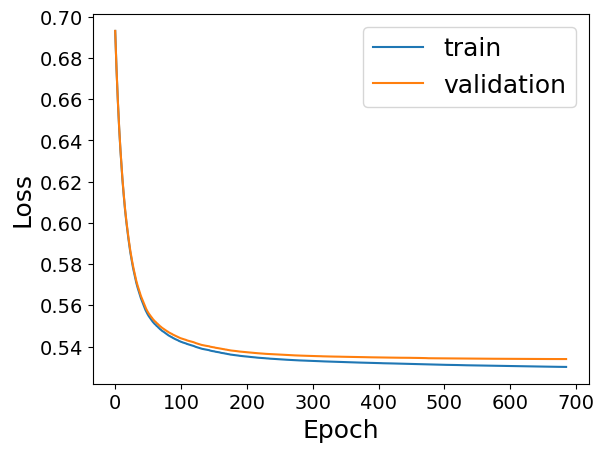

In [149]:
train_loss = [-s for s in clf.train_score_]
val_loss   = [-s for s in clf.validation_score_]

plt.plot(train_loss, label="train")
plt.plot(val_loss, label="validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


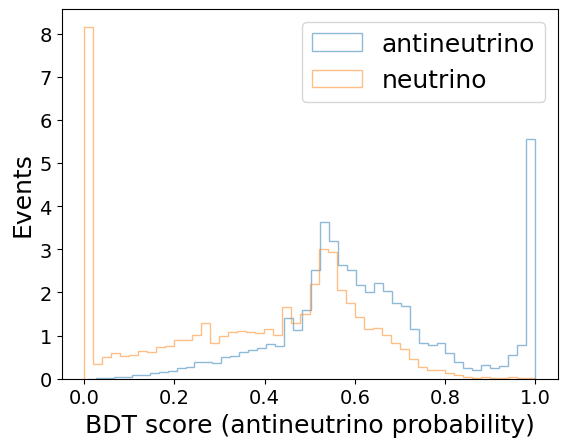

[0.32071913 0.69323453 0.00094951 ... 0.63706799 0.05654865 0.54433349]


In [150]:


score = clf.predict_proba(X_test)[:,1]


plt.hist(score[y_test==1], bins=50, alpha=0.5, label="antineutrino", density = True,  histtype="step")
plt.hist(score[y_test==0], bins=50, alpha=0.5, label="neutrino", density = True, histtype="step")

plt.xlabel("BDT score (antineutrino probability)")
plt.ylabel("Events")
plt.legend()
plt.show()

print(score)

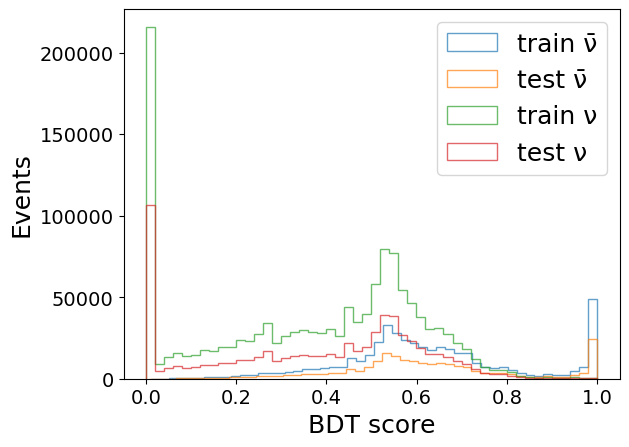

In [151]:
score_train = clf.predict_proba(X_train)[:,1]
score_test  = clf.predict_proba(X_test)[:,1]

plt.hist(score_train[y_train==1], bins=50, alpha=0.7, label="train ν̄",histtype = 'step')
plt.hist(score_test[y_test==1],  bins=50, alpha=0.7, label="test ν̄", histtype = 'step')

plt.hist(score_train[y_train==0], bins=50, alpha=0.7, label="train ν", histtype = 'step')
plt.hist(score_test[y_test==0],  bins=50, alpha=0.7, label="test ν", histtype = 'step')

plt.xlabel("BDT score")
plt.ylabel("Events")
plt.legend()
plt.show()



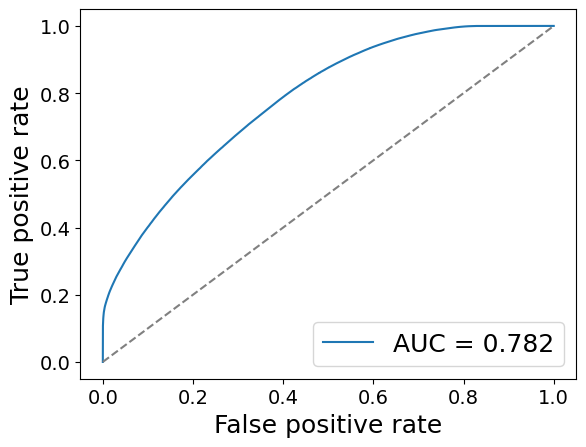

In [152]:
from sklearn.metrics import roc_curve, auc

probs = clf.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1], linestyle="--", color="gray")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend()
plt.show()


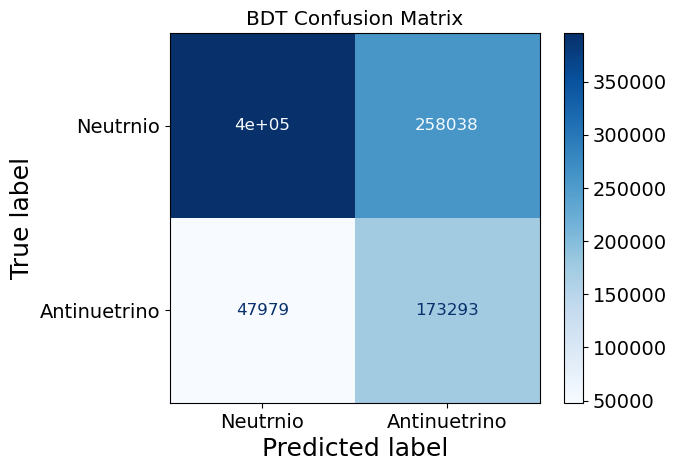

In [153]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Neutrnio', 'Antinuetrino'])
disp.plot(cmap=plt.cm.Blues)
plt.title("BDT Confusion Matrix")
plt.show()

In [154]:
from sklearn.inspection import permutation_importance
r = permutation_importance(clf, X_data, y_data, n_repeats=5)


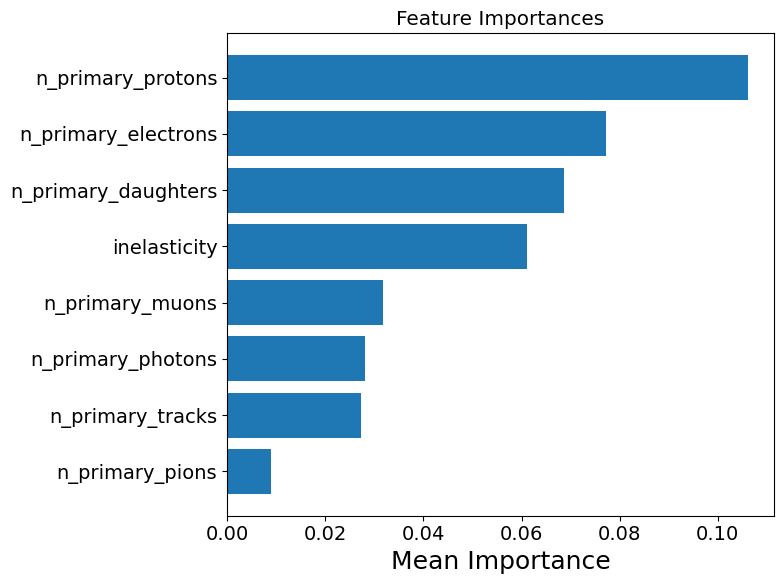

In [155]:
means = r["importances_mean"]
sorted_idx = np.argsort(means)

plt.figure(figsize=(8, 6))
plt.barh(
    [feature_columns[i] for i in sorted_idx],
    means[sorted_idx]
)
plt.xlabel("Mean Importance")
plt.title("Feature Importances")
plt.tight_layout()
plt.show()

In [156]:
from sklearn.metrics import log_loss

x = log_loss(y_true=y_test, y_pred=probs)
print(x)

0.5363779220242445


In [157]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=['Neutrino', 'Antineutrino']))

              precision    recall  f1-score   support

    Neutrino       0.89      0.61      0.72    653567
Antineutrino       0.40      0.78      0.53    221272

    accuracy                           0.65    874839
   macro avg       0.65      0.69      0.63    874839
weighted avg       0.77      0.65      0.67    874839



874839
2651027
874838.91


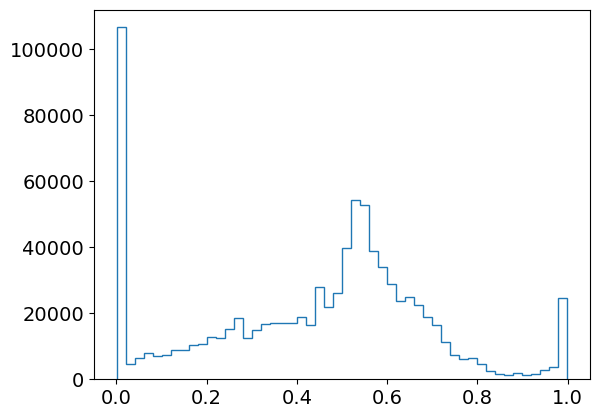

In [158]:
plt.hist(score, histtype="step", bins=50, label="test" )
print(len(score))
print(len(y_data))
print(0.33*len(y_data))

In [159]:
hard_predictions = clf.predict(X_data)
probs = clf.predict_proba(X_data)
decision_scores = clf.decision_function(X_data)


results_df = pd.DataFrame({
    'true_label': y_data,
    'predicted_label': hard_predictions,
    'prob_neutrino': probs[:, 0],
    'prob_antineutrino': probs[:, 1],
    'decision_score': decision_scores
})



print(results_df.head())

   true_label  predicted_label  prob_neutrino  prob_antineutrino  \
0           1                1       0.215833           0.784167   
1           1                0       0.756460           0.243540   
2           1                1       0.322442           0.677558   
3           0                0       0.999278           0.000722   
4           0                1       0.457848           0.542152   

   decision_score  
0        1.290116  
1       -1.133368  
2        0.742573  
3       -7.233317  
4        0.169011  


In [160]:
score_column = results_df['prob_antineutrino']

In [161]:
all_probs = clf.predict_proba(X_data)[:, 1]

final_output = pd.DataFrame({
    'event_index': data['event_index'],
    'bdt_score': all_probs
})

final_output.to_csv("cheated_bdt_scores_with_index_old_params.csv", index=False)

In [162]:
final_output

,event_index,bdt_score
0,0,0.784167
1,1,0.243540
2,2,0.677558
4,4,0.000722
5,5,0.542152
...,...,...
2884698,2884698,0.510679
2884699,2884699,0.459437
2884700,2884700,0.187033
2884701,2884701,0.682598


In [164]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_data, all_probs)
j_scores = tpr - fpr
best_threshold = thresholds[np.argmax(j_scores)]
# find threshold where TPR ≈ TNR 
best_threshold = thresholds[np.argmin(np.abs(tpr - (1 - fpr)))]
print(best_threshold)

0.5341561102210631
